In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation_cla as pred_model_cla

import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, precision_score, recall_score

from sklearn.model_selection import train_test_split
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

In [2]:
load_prepared_data = pd.read_excel('../Data/QSPR_epoxidation_classifier.xlsx')
load_prepared_data.head(1)

,Reaction number,SMILES,Reaction ID,Reaction: Links to Reaxys,Reactant,Product,Reaction,Number of Reaction Steps,Time (Reaction Details) [h],Temperature (Reaction Details) [C],...,Reagent,SMILES ligand,SMILES mieszanina reakcyjna,% mol liganda,% mol magnezu,stężenie katalizatora [mol/dm3],stężenie substratu M,Solvent (Reaction Details),References,Links to Reaxys
0,1,CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1,28455091.0,https://www.reaxys.com/reaxys/secured/hopinto....,4-methyl-chalcone,"(2R,3S)-epoxy-3-(4-methylphenyl)-1-phenylpropa...",CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1>>CC1=CC=C(C=...,1.0,72.0,0.0,...,"tert.-butylhydroperoxide; (R,R)-(-)-2,6-bis[2-...",OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](CCC3)N3CC4=...,CC(C)(OO)C.OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](...,12.0,20.0,0.024,0.2,tetrahydrofuran; toluene,"Article; Jaszczewska-Adamczak, Joanna A.; Mlyn...",https://www.reaxys.com/reaxys/secured/hopinto....


In [3]:
molecular_descriptors_df = pred_model_cla.prepare_data('../Data/QSPR_epoxidation_classifier.xlsx')

100%|██████████████████████████████████████████████████████████████████████████████████| 67/67 [00:01<00:00, 37.03it/s]


Data size (rows, columns): (67, 3874)
Data size after first reduction (rows, columns): (67, 3329)
Data size after second reduction (rows, columns): (67, 1428)


In [4]:
molecular_descriptors_df.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2037,C_FP_2041,epox_cla
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,21.562500,5.820625,3.375000,6.687500,154.056327,85.083842,1.696221,5.941753,3.793403,7.362468,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


# EE

In [5]:
target = 'epox_cla'
data = molecular_descriptors_df
#data[target] = load_prepared_data['ee']
data.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2037,C_FP_2041,epox_cla
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,21.562500,5.820625,3.375000,6.687500,154.056327,85.083842,1.696221,5.941753,3.793403,7.362468,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


## Classification first

In [6]:
model_cla, train_acc, test_acc, train_prec, test_prec, data_to_be_prepared, corr_cla, target_column_name  = pred_model_cla.prepare_data_and_create_model(molecular_descriptors_df=data, 
                                                                                                    correlation_threshold=0.42, 
                                                                                                    standardization=False, 
                                                                                                    model_type='RandomForestClassifier',
                                                                                                    target_column_name = target,
                                                                                                    n_estimators_ = 2,
                                                                                                    random_state=28,
                                                                                                    train_test_split_=True, 
                                                                                                    verbose=True)

I am not doing standardization...
  molecular descriptor name
0                    AATS0Z
1                  AATS0are
2                    AATS0d
3                   AATS0dv
4                    AATS0i
  molecular descriptor name  corr_value
0                    AATS0Z    0.071849
1                  AATS0are    0.128205
2                    AATS0d    0.294886
3                   AATS0dv    0.225567
4                    AATS0i   -0.252806
  molecular descriptor name  corr_value  absolute correlation value
0                    AATS0Z    0.071849                    0.071849
1                  AATS0are    0.128205                    0.128205
2                    AATS0d    0.294886                    0.294886
3                   AATS0dv    0.225567                    0.225567
4                    AATS0i   -0.252806                    0.252806
     molecular descriptor name  corr_value  absolute correlation value
415                      C2SP2    0.446787                    0.446787
521     

In [7]:
X_train, X_test, y_train, y_test = train_test_split(data[corr_cla['molecular descriptor name']], data[target], test_size=0.15, random_state=28)

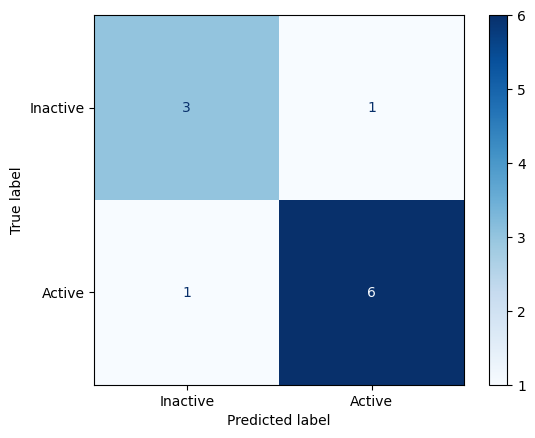

In [8]:
cm = confusion_matrix(y_test, model_cla.predict(X_test[corr_cla['molecular descriptor name']]))
# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap=plt.cm.Blues)
#plt.title('Confusion Matrix')
plt.savefig('Test_conf_matrix.pdf', bbox_inches='tight')
plt.show()

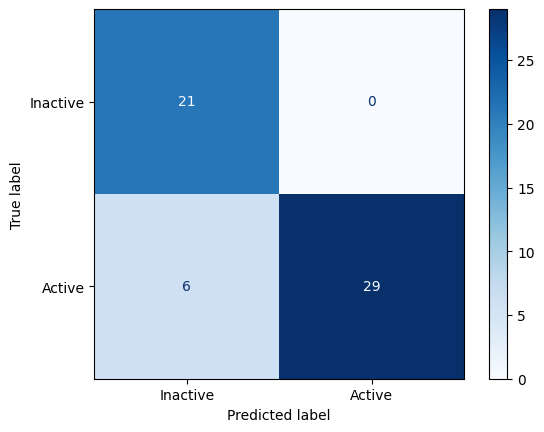

In [9]:
cm = confusion_matrix(y_train, model_cla.predict(X_train[corr_cla['molecular descriptor name']]))
# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap=plt.cm.Blues)
#plt.title('Confusion Matrix')
plt.savefig('Train_conf_matrix.pdf', bbox_inches='tight')
plt.show()

In [10]:
# save
joblib.dump(model_cla, "models/random_forest_model_3_estimators_EE_cla.joblib")

['models/random_forest_model_3_estimators_EE_cla.joblib']

In [11]:
load_unseen_data = pd.read_excel('../Data/9_test_reactions.xlsx')

In [12]:
df_unseen = load_unseen_data[['SMILES', 'ee', 'ee cla']]

In [13]:
df__ = pred_model_cla.prepare_data('../Data/9_test_reactions.xlsx')

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00,  9.82it/s]


Data size (rows, columns): (9, 3874)
Data size after first reduction (rows, columns): (9, 3333)
Data size after second reduction (rows, columns): (9, 1113)


In [14]:
predicted_activity_cla = model_cla.predict(df__[corr_cla['molecular descriptor name']])

In [15]:
df_unseen['Predicted cla ee'] = predicted_activity_cla

In [16]:
print("Accuracy: ", accuracy_score(df_unseen['ee cla'], df_unseen['Predicted cla ee']))
print("Precision: ", precision_score(df_unseen['ee cla'], df_unseen['Predicted cla ee'])) #, average='macro'
print("Confusion Matrix:\n", confusion_matrix(df_unseen['ee cla'], df_unseen['Predicted cla ee']))
cm = confusion_matrix(df_unseen['ee cla'], df_unseen['Predicted cla ee'])
print("Classification Report:\n", classification_report(df_unseen['ee cla'], df_unseen['Predicted cla ee']))

Accuracy:  0.7777777777777778
Precision:  0.8571428571428571
Confusion Matrix:
 [[1 1]
 [1 6]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.86      0.86      0.86         7

    accuracy                           0.78         9
   macro avg       0.68      0.68      0.68         9
weighted avg       0.78      0.78      0.78         9



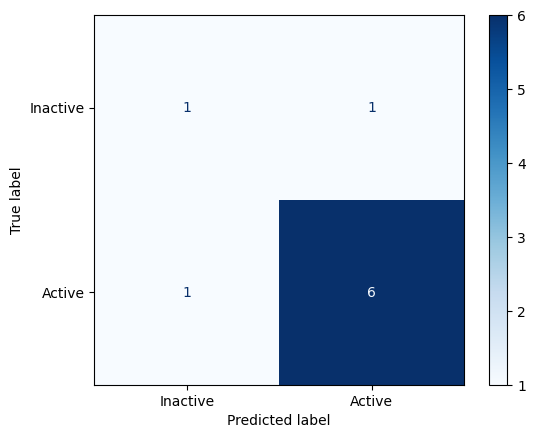

In [17]:
# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap=plt.cm.Blues)
#plt.title('Confusion Matrix')
plt.savefig('Test_2_conf_matrix.pdf', bbox_inches='tight')
plt.show()

In [18]:
df_unseen

,SMILES,ee,ee cla,Predicted cla ee
0,ClC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1,93,1,1
1,O=C1CCCC=C1,44,1,1
2,ClC1=C(C(C=CC2=CC=CC=C2)=O)C=CC=C1,88,1,1
3,O=C(C=CC1=CC2=CC=CC=C2O1)C1=CC=CC=C1,99,1,1
4,CCCCC=CC(C1=CC=CC=C1)=O,88,1,0
5,O=C(/C1=C/C=C/C2=CC=CC=C2)C3=C(CC1)C=CC=C3,0,0,1
6,O=C(/C=C/C1=CC=CC=C1)OCC,0,0,0
7,O=C(C1=CC=C(N(=O)=O)C=C1)C=CC2=CC=CC=C2,48,1,1
8,FC1=CC=C(C=CC(=O)C2=CC=C(F)C=C2)C=C1,91,1,1


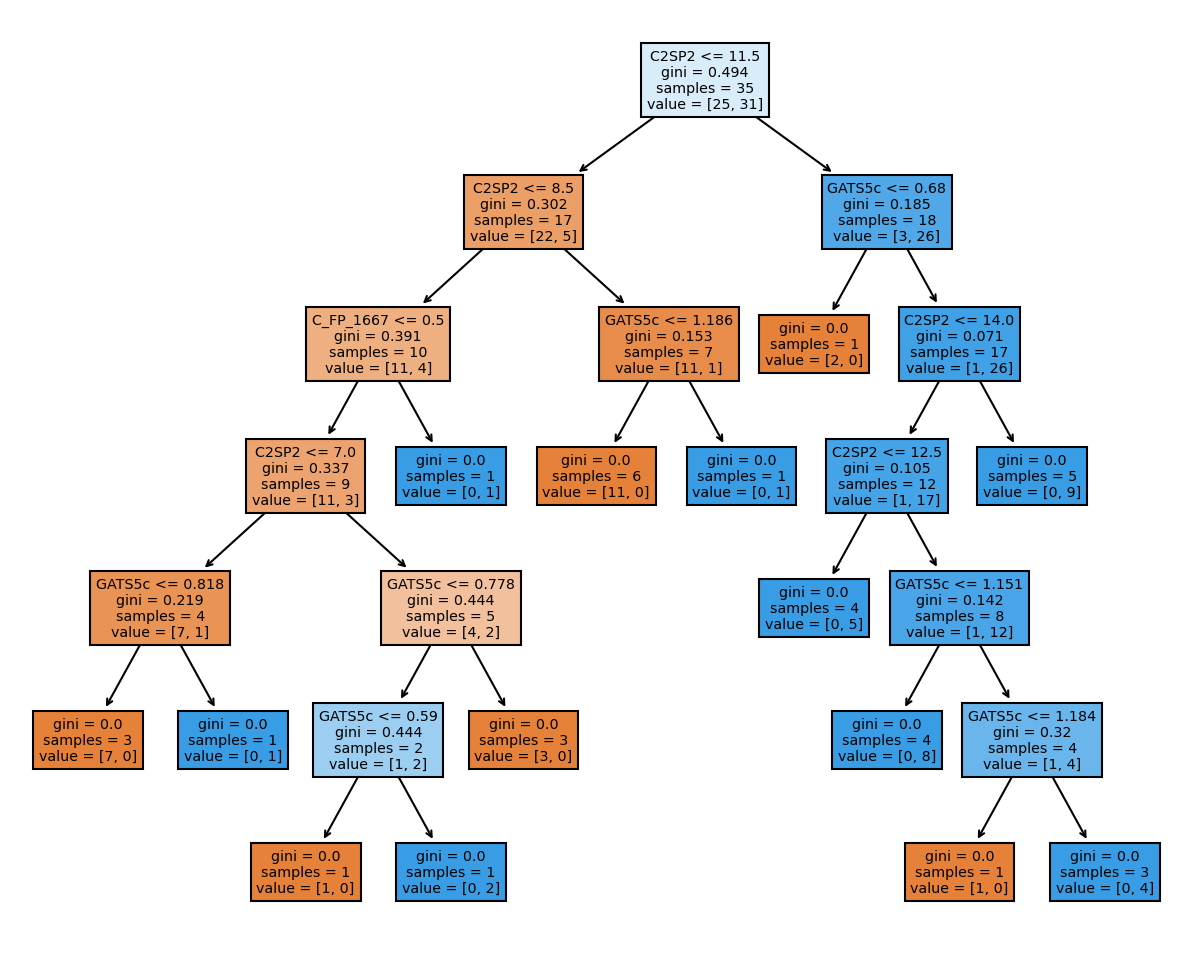

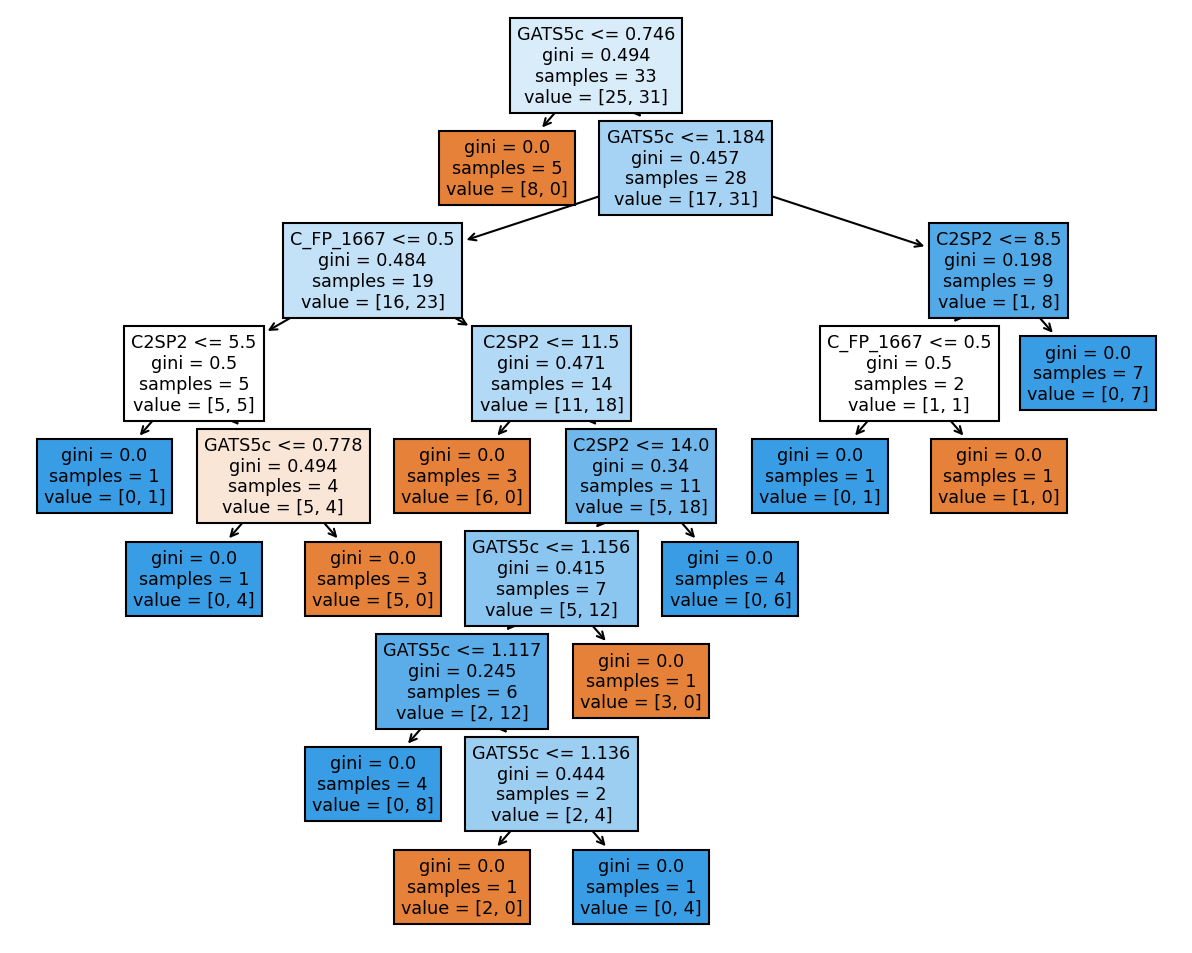

In [19]:
for x, decision_tree in enumerate(model_cla.estimators_):
    plt.figure(figsize=(10,8), dpi=150)
    plot_tree(decision_tree, feature_names=list(corr_cla['molecular descriptor name']),
             filled=True)
    plt.savefig('models/random_forest_8_'+str(x)+'_model_EE_cla.pdf',bbox_inches = "tight")

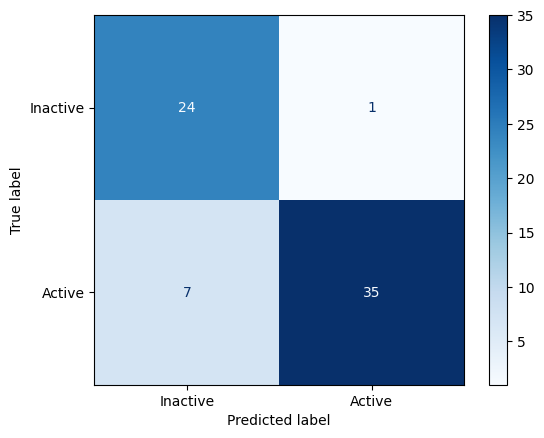

In [20]:
X, y = data[corr_cla['molecular descriptor name']], data[target]

cm = confusion_matrix(y, model_cla.predict(X[corr_cla['molecular descriptor name']]))
# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap=plt.cm.Blues)
#plt.title('Confusion Matrix')
plt.savefig('All_conf_matrix.pdf', bbox_inches='tight')
plt.show()

In [21]:
X.head(3)

,C2SP2,GATS5c,C_FP_1667
0,12,1.105601,1.0
1,13,1.433963,1.0
2,13,1.138368,1.0


In [22]:
data.head(3)

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2037,C_FP_2041,epox_cla
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


In [23]:
predicted_activity_cla = model_cla.predict(data[corr_cla['molecular descriptor name']])
data['Predicted cla ee'] = predicted_activity_cla

In [24]:
print("Accuracy: ", accuracy_score(data['epox_cla'], data['Predicted cla ee']))
print("Precision: ", precision_score(data['epox_cla'], data['Predicted cla ee'])) #, average='macro'
print("Confusion Matrix:\n", confusion_matrix(data['epox_cla'], data['Predicted cla ee']))
cm = confusion_matrix(data['epox_cla'], data['Predicted cla ee'])
print("Classification Report:\n", classification_report(data['epox_cla'], data['Predicted cla ee']))

Accuracy:  0.8805970149253731
Precision:  0.9722222222222222
Confusion Matrix:
 [[24  1]
 [ 7 35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.96      0.86        25
           1       0.97      0.83      0.90        42

    accuracy                           0.88        67
   macro avg       0.87      0.90      0.88        67
weighted avg       0.90      0.88      0.88        67

